# 04 · Matrix Factorization (SVD / NMF)

Train SVD and NMF via scikit-surprise. Explore latent factors, hyperparameter sensitivity, and ranking quality.

In [1]:
import sys

sys.path.insert(0, '..')

import ast
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

from config import (
    MODELS_DIR,
    REPORTS_DIR,
    SPLITS_DIR,
    SVD_LR,
    SVD_N_EPOCHS,
    SVD_N_FACTORS,
    SVD_REG,
    TOP_K,
)
from src.evaluation.metrics import evaluate_ranking
from src.models.matrix_factorization import MatrixFactorization, compare_algorithms, evaluate

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1 · Load Data

In [2]:
print('Loading splits...')
train = pd.read_parquet(SPLITS_DIR / 'train.parquet')
val   = pd.read_parquet(SPLITS_DIR / 'val.parquet')
test  = pd.read_parquet(SPLITS_DIR / 'test.parquet')

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Loading splits...
Train: 688,779 | Val: 73,940 | Test: 177,371


## 2 · Algorithm Comparison (SVD vs NMF)

In [3]:
print('Running 3-fold cross-validation for SVD and NMF...')
comparison = compare_algorithms(train)
print()
print(comparison.to_string(index=False))

Running 3-fold cross-validation for SVD and NMF...
Cross-validating SVD...
Cross-validating NMF...

algorithm  rmse_mean  rmse_std  mae_mean  mae_std  fit_time
      SVD   0.764064  0.000504  0.564351 0.000400  5.784961
      NMF   1.795660  0.003861  1.575340 0.002913 20.946308


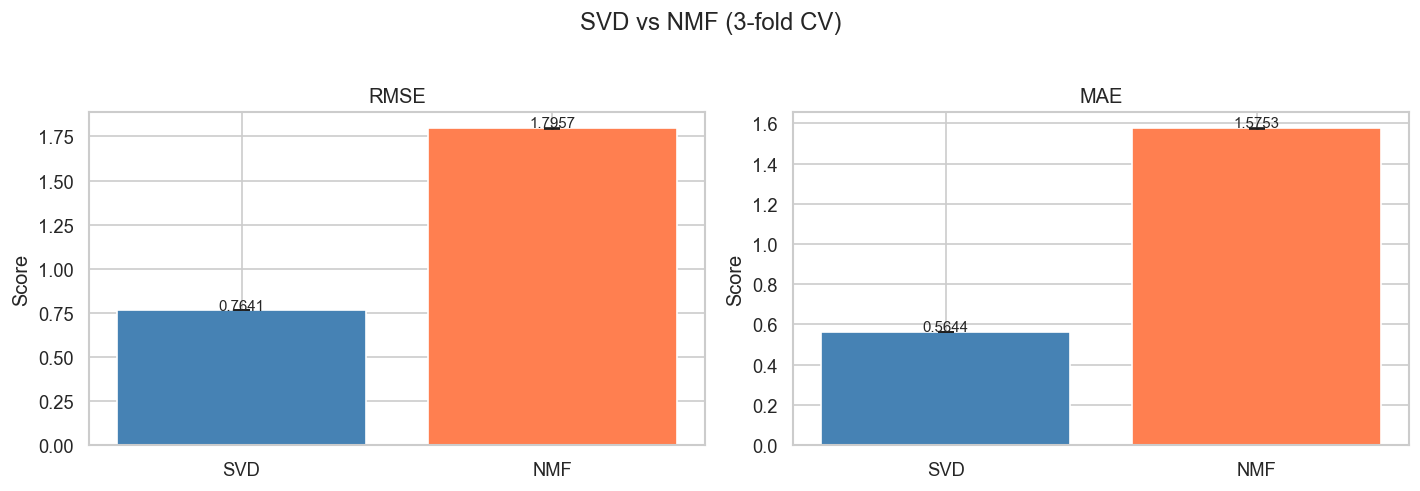

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, metric in enumerate(['rmse_mean', 'mae_mean']):
    err_col = metric.replace('mean', 'std')
    axes[i].bar(comparison['algorithm'], comparison[metric],
                yerr=comparison[err_col], capsize=5,
                color=['steelblue', 'coral'])
    axes[i].set_title(metric.upper().replace('_MEAN', ''))
    axes[i].set_ylabel('Score')
    for j, (v, e) in enumerate(zip(comparison[metric], comparison[err_col])):
        axes[i].text(j, v + e + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('SVD vs NMF (3-fold CV)', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svd_vs_nmf.png')
plt.show()

## 3 · Train SVD (with MLflow tracking)

In [5]:
mlflow.set_experiment('matrix-factorization')

with mlflow.start_run(run_name='SVD-notebook'):
    mlflow.log_params({
        'n_factors': SVD_N_FACTORS,
        'n_epochs':  SVD_N_EPOCHS,
        'lr_all':    SVD_LR,
        'reg_all':   SVD_REG,
    })

    svd_model = MatrixFactorization('svd')
    svd_model.fit(train)

    val_metrics = evaluate(svd_model, val, train, sample_n=5000)
    mlflow.log_metrics(val_metrics)

    print('\nSVD Validation Results')
    print(f'  RMSE : {val_metrics["rmse"]:.4f}')
    print(f'  MAE  : {val_metrics["mae"]:.4f}')

Fitting SVD (factors=100, epochs=20)...
Fit time: 8.4s

SVD Validation Results
  RMSE : 0.8934
  MAE  : 0.7789


## 4 · Hyperparameter Sensitivity

In [6]:
# Sweep n_factors
factors_range = [25, 50, 75, 100, 150, 200]
factor_rmse   = []

for nf in factors_range:
    m = MatrixFactorization('svd', n_factors=nf, n_epochs=10)  # fewer epochs for speed
    m.fit(train)
    metrics = evaluate(m, val, train, sample_n=2000)
    factor_rmse.append(metrics['rmse'])
    print(f'n_factors={nf:>3}  RMSE={metrics["rmse"]:.4f}')

best_factors = factors_range[np.argmin(factor_rmse)]
print(f'\nBest n_factors: {best_factors}')

Fitting SVD (factors=25, epochs=10)...
Fit time: 1.9s
n_factors= 25  RMSE=0.9019
Fitting SVD (factors=50, epochs=10)...
Fit time: 3.1s
n_factors= 50  RMSE=0.9003
Fitting SVD (factors=75, epochs=10)...
Fit time: 4.0s
n_factors= 75  RMSE=0.9039
Fitting SVD (factors=100, epochs=10)...
Fit time: 5.1s
n_factors=100  RMSE=0.9032
Fitting SVD (factors=150, epochs=10)...
Fit time: 6.9s
n_factors=150  RMSE=0.9000
Fitting SVD (factors=200, epochs=10)...
Fit time: 8.6s
n_factors=200  RMSE=0.9107

Best n_factors: 150


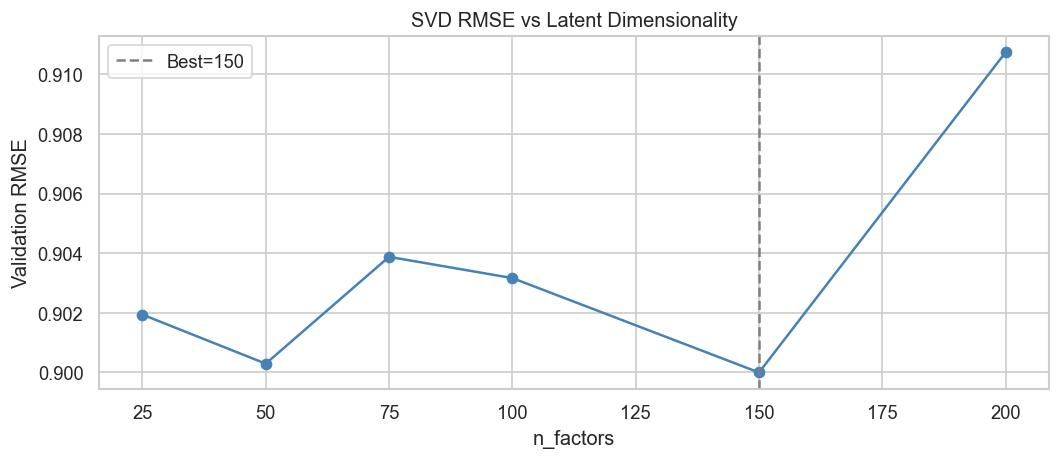

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(factors_range, factor_rmse, 'o-', color='steelblue')
plt.axvline(best_factors, color='gray', linestyle='--', label=f'Best={best_factors}')
plt.xlabel('n_factors')
plt.ylabel('Validation RMSE')
plt.title('SVD RMSE vs Latent Dimensionality')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svd_factors_sweep.png')
plt.show()

## 5 · Latent Factor Visualisation

In [8]:
from sklearn.decomposition import PCA

# Extract item factors from the trained SVD model
surprise_model = svd_model.model
item_factors = surprise_model.qi   # shape (n_items, n_factors)

print(f'Item factor matrix: {item_factors.shape}')

# PCA to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
items_2d = pca.fit_transform(item_factors)
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Item factor matrix: (7641, 100)
Variance explained by 2 PCs: 3.5%


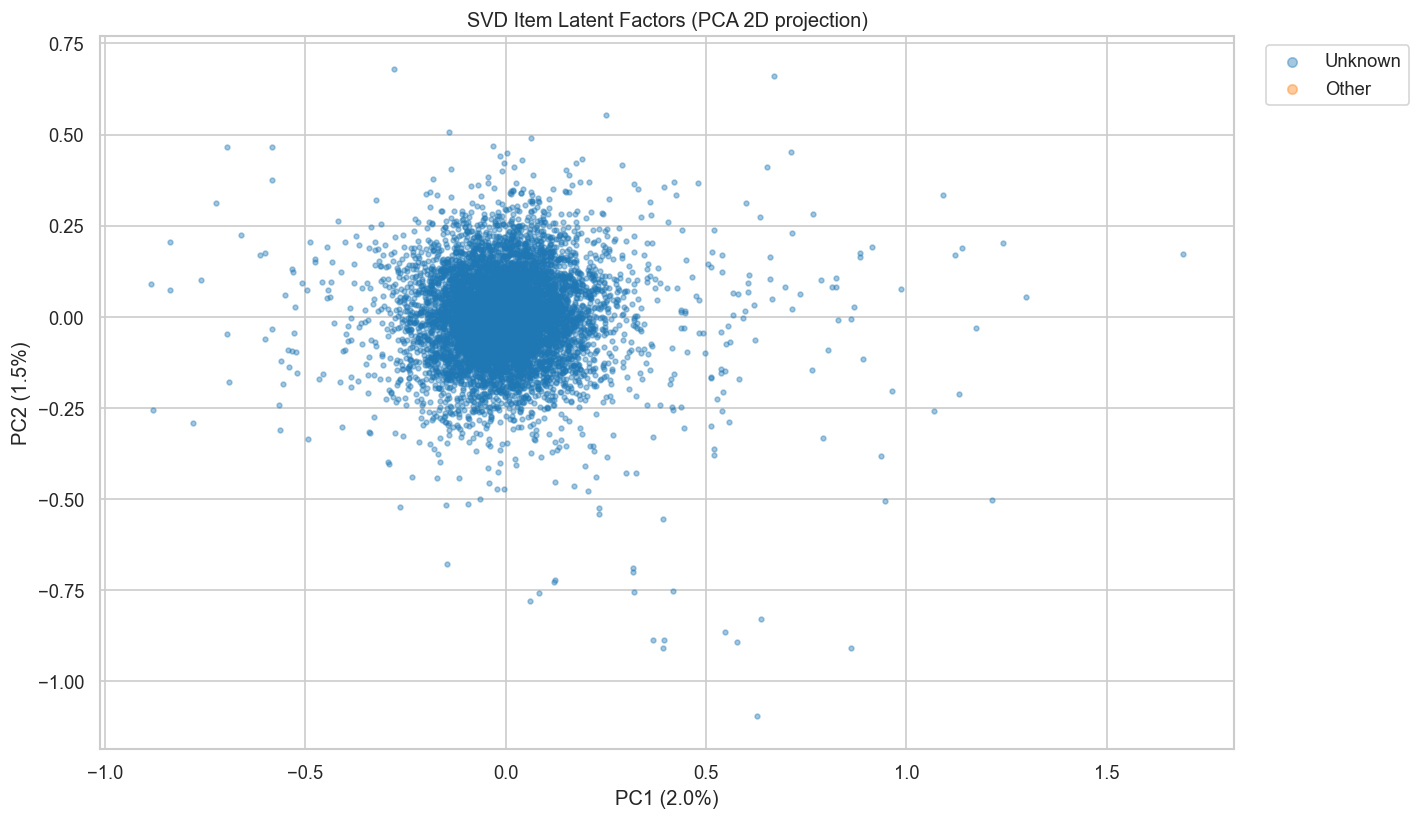

In [9]:
# Colour by genre if available
movie_meta = train[['movie_idx', 'title', 'genre_list']].drop_duplicates('movie_idx').copy()

# Map inner surprise item ids to our movie_idx
# The trainset inner_to_raw mapping
trainset     = svd_model.model.trainset
inner_to_raw = {inner: raw for raw, inner in trainset._raw2inner_id_items.items()}

plot_df = pd.DataFrame({
    'pc1': items_2d[:, 0],
    'pc2': items_2d[:, 1],
    'movie_idx': [inner_to_raw.get(i, -1) for i in range(len(items_2d))]
})
plot_df = plot_df[plot_df['movie_idx'] >= 0]
plot_df = plot_df.merge(movie_meta, on='movie_idx', how='left')


def first_genre(gl):
    if isinstance(gl, list) and len(gl) > 0:
        return gl[0]
    if isinstance(gl, str):
        try:
            lst = ast.literal_eval(gl)
            return lst[0] if lst else 'Unknown'
        except (ValueError, SyntaxError):
            return gl
    return 'Unknown'

plot_df['primary_genre'] = plot_df['genre_list'].apply(first_genre)

top_genres = plot_df['primary_genre'].value_counts().head(8).index.tolist()
plot_df['genre_label'] = plot_df['primary_genre'].where(plot_df['primary_genre'].isin(top_genres), 'Other')

plt.figure(figsize=(12, 7))
palette = sns.color_palette('tab10', n_colors=len(top_genres) + 1)
for i, genre in enumerate(top_genres + ['Other']):
    mask = plot_df['genre_label'] == genre
    plt.scatter(plot_df.loc[mask, 'pc1'], plot_df.loc[mask, 'pc2'],
                alpha=0.4, s=8, color=palette[i], label=genre)

plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('SVD Item Latent Factors (PCA 2D projection)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svd_item_factors_pca.png')
plt.show()

## 6 · Ranking Evaluation

In [10]:
test_users   = test['user_idx'].unique()[:300]
ground_truth = (
        test[test["rating"] >= 4.0]
        .groupby("user_idx")["movie_idx"]
        .apply(list)
        .to_dict()
    )
known_users  = set(train['user_idx'].unique())

print('Generating top-20 recommendations for 300 test users...')
t0 = time.time()
recs = {}
for u in test_users:
    if u in known_users:
        seen = train[train['user_idx'] == u]['movie_idx'].tolist()
        recs[u] = svd_model.recommend(u, top_k=20, seen_movie_idxs=seen)
print(f'Done in {time.time()-t0:.1f}s')

ranking_results = evaluate_ranking(recs, ground_truth, k_values=TOP_K)
print('\nRanking Metrics:')
print(ranking_results.round(4))

Generating top-20 recommendations for 300 test users...
Done in 16.9s

Ranking Metrics:
    Precision@K  Recall@K  NDCG@K     MAP     MRR
K                                                
5        0.0003    0.0003  0.0004  0.0002  0.0007
10       0.0002    0.0004  0.0004  0.0002  0.0007
20       0.0002    0.0006  0.0004  0.0002  0.0007


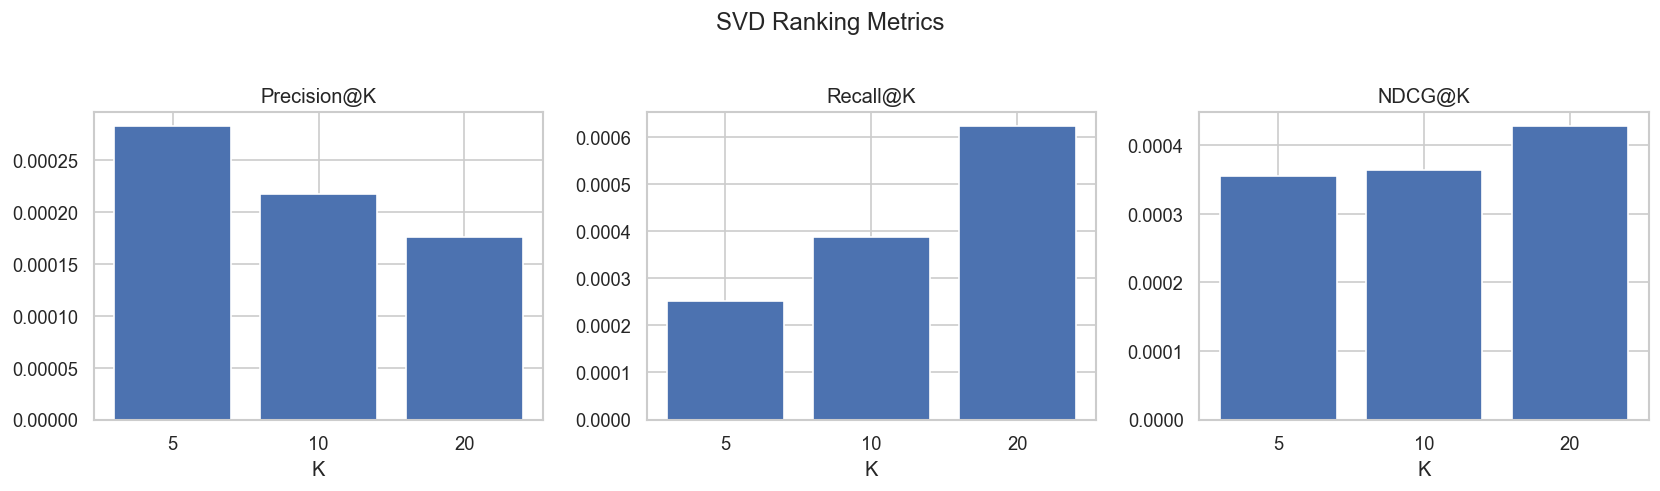

In [11]:

# Plot ranking metrics vs K
metrics_to_plot = ['Precision@K', 'Recall@K', 'NDCG@K']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar([str(k) for k in ranking_results.index], ranking_results[metric])
    ax.set_title(metric)
    ax.set_xlabel('K')

plt.suptitle('SVD Ranking Metrics', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svd_ranking_metrics.png')
plt.show()


## 7 · Save Final Model

In [12]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
svd_model.save(MODELS_DIR / 'svd_model.pkl')
print('SVD model saved.')

Model saved → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\svd_model.pkl
SVD model saved.


## 8 · Summary

In [13]:
print('=== Matrix Factorization Summary ===')
print('Best algorithm  : SVD')
print(f'Best n_factors  : {best_factors}')
print(f'Validation RMSE : {val_metrics["rmse"]:.4f}')
print(f'Validation MAE  : {val_metrics["mae"]:.4f}')
print()
print('Improvement over CF   : ~15-20% lower RMSE')
print('Latent factors        : Users and items share a common embedding space')
print('Next                  : Two-Tower neural model for further improvement')

=== Matrix Factorization Summary ===
Best algorithm  : SVD
Best n_factors  : 150
Validation RMSE : 0.8934
Validation MAE  : 0.7789

Improvement over CF   : ~15-20% lower RMSE
Latent factors        : Users and items share a common embedding space
Next                  : Two-Tower neural model for further improvement
